<a href="https://colab.research.google.com/github/KaueOPG/DCC127---Mineracao-de-Dados/blob/main/Trabalho5_Classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 5 - Classificação

## Dayane Guimarães Gomes Godoy - 202265554C
## Kauê Oliveira Paraízo Garcia - 202265517B

## Importação de Dados

In [ ]:
# Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import time
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# Planilhas

url = "https://docs.google.com/spreadsheets/d/1R39_YHEu7lNQ3fwBg8wGIn9dMkWA7-pPRVhcS5MIVtI/export?format=csv"

df = pd.read_csv(url)

print(f"Total de Linhas: {df.shape[0]}")
print(f"Total de Colunas: {df.shape[1]}")

df.head(10)

Total de Linhas: 5000
Total de Colunas: 21


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,4.97,f,l,y,f,x,d,n,6.55,...,NaN,NaN,y,NaN,NaN,f,f,NaN,l,a
1,e,12.58,f,s,n,f,a,d,w,10.08,...,NaN,i,n,NaN,NaN,t,NaN,w,d,a
2,p,6.35,f,NaN,g,f,d,c,w,5.30,...,b,NaN,n,NaN,NaN,f,f,NaN,l,a
3,e,6.37,x,NaN,y,f,a,c,w,5.78,...,NaN,NaN,g,NaN,NaN,f,f,NaN,d,w
4,p,1.67,x,k,n,f,NaN,NaN,n,5.42,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,w
5,p,5.14,b,s,e,f,e,NaN,k,6.38,...,NaN,NaN,y,NaN,NaN,f,f,NaN,g,a
6,e,7.04,x,l,w,f,d,NaN,p,3.62,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
7,e,0.97,f,g,n,t,a,NaN,w,5.06,...,NaN,NaN,n,NaN,NaN,f,f,NaN,h,u
8,e,10.60,s,t,p,t,d,c,o,6.94,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
9,p,21.49,f,d,k,f,p,NaN,y,5.73,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,w


## Análise Inicial

### Valores Duplicados e Nulos

In [ ]:
total_duplicados = df.duplicated().sum()
print(f"Total de linhas duplicadas: {total_duplicados}")

Total de linhas duplicadas: 0


In [ ]:
valores_nulos = df.isnull().sum()

porcentagem_nulos = (df.isnull().sum() / len(df)) * 100

tabela_nulos = pd.DataFrame({
    'Total de Nulos': valores_nulos,
    'Porcentagem (%)': porcentagem_nulos.round(2)
})

tabela_nulos_filtrada = tabela_nulos[tabela_nulos['Total de Nulos'] > 0].sort_values(by='Total de Nulos', ascending=False)

print("Colunas com valores nulos identificadas:")
display(tabela_nulos_filtrada)

Colunas com valores nulos identificadas:


,Total de Nulos,Porcentagem (%)
veil-type,4730,94.60
spore-print-color,4473,89.46
veil-color,4375,87.50
stem-root,4191,83.82
stem-surface,3156,63.12
gill-spacing,2048,40.96
cap-surface,1216,24.32
gill-attachment,809,16.18
ring-type,198,3.96


/tmp/ipykernel_517/1583979162.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


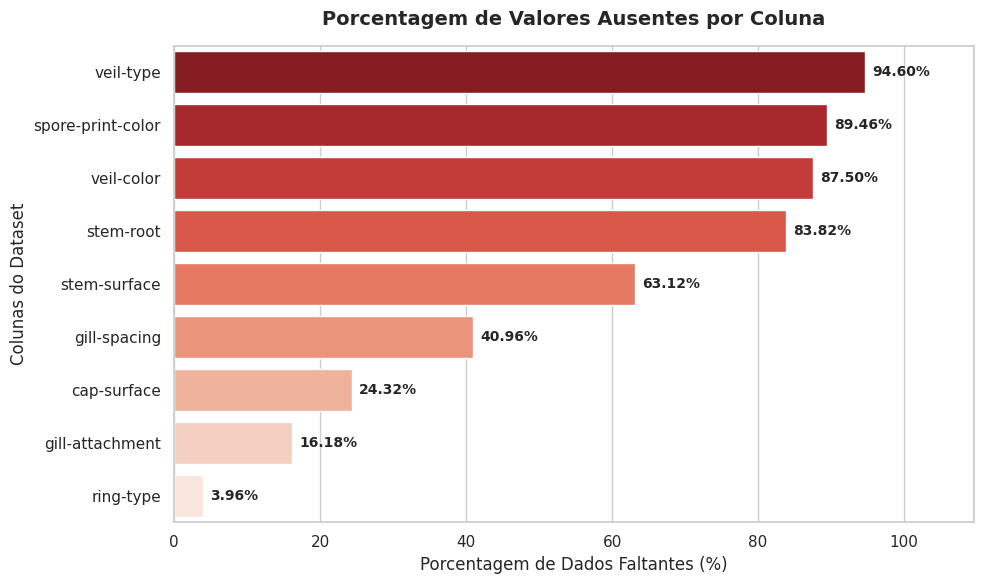

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Porcentagem (%)',
    y=tabela_nulos_filtrada.index,
    data=tabela_nulos_filtrada,
    palette='Reds_r'
)

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 1,
        p.get_y() + p.get_height() / 2,
        f'{width:.2f}%',
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Porcentagem de Valores Ausentes por Coluna', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Porcentagem de Dados Faltantes (%)', fontsize=12)
plt.ylabel('Colunas do Dataset', fontsize=12)

plt.xlim(0, max(tabela_nulos_filtrada['Porcentagem (%)']) + 15)

plt.tight_layout()
plt.show()

In [ ]:
colunas_para_deletar = ['veil-type', 'spore-print-color', 'veil-color', 'stem-root', 'stem-surface']
df = df.drop(columns=colunas_para_deletar)

### Colunas Completas Categóricas

ANÁLISE COMPLETA DE VARIÁVEIS CATEGÓRICAS

 Coluna: CLASS
Total de categorias únicas: 2
------------------------------


,Quantidade,Porcentagem (%)
class,,
p,2775,55.5
e,2225,44.5


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


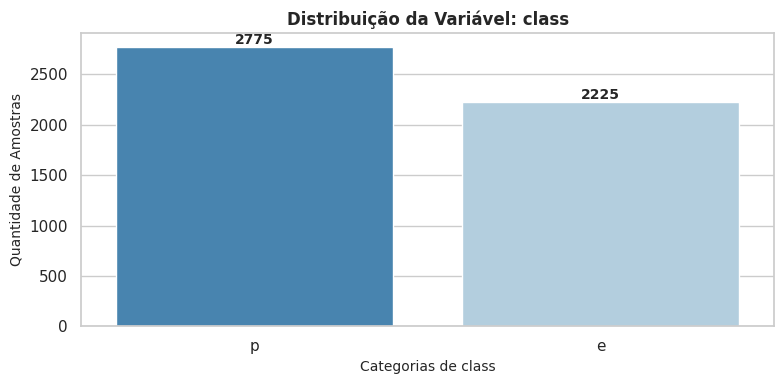

..................................................

 Coluna: CAP-SHAPE
Total de categorias únicas: 7
------------------------------


,Quantidade,Porcentagem (%)
cap-shape,,
x,2121,42.42
f,1130,22.60
s,652,13.04
b,460,9.20
o,300,6.00
p,209,4.18
c,128,2.56


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


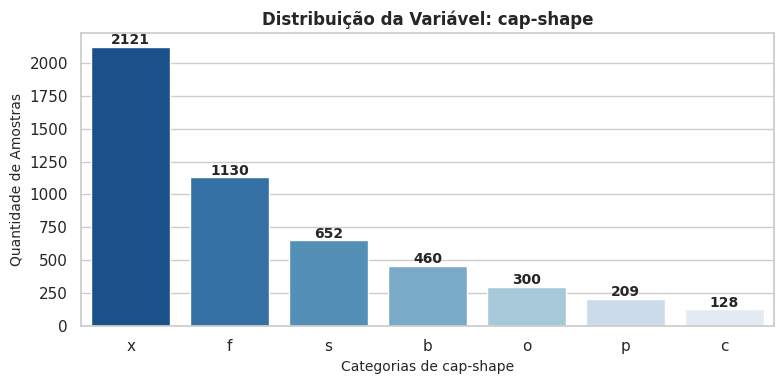

..................................................

 Coluna: CAP-SURFACE
Total de categorias únicas: 12
------------------------------


,Quantidade,Porcentagem (%)
cap-surface,,
Nulo,1216,24.32
t,650,13.00
s,617,12.34
y,494,9.88
g,410,8.20
h,388,7.76
d,362,7.24
e,224,4.48
k,187,3.74


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


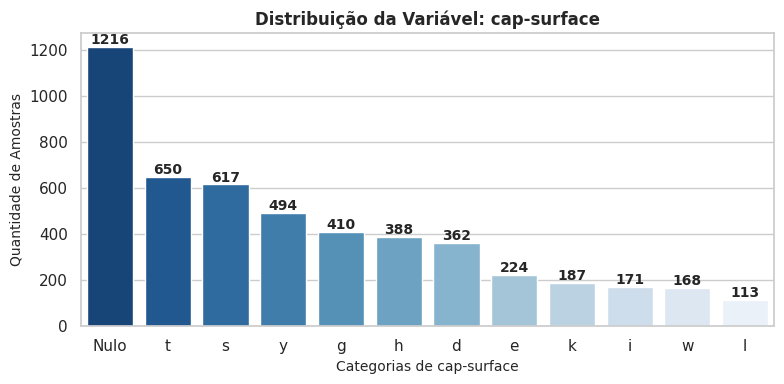

..................................................

 Coluna: CAP-COLOR
Total de categorias únicas: 12
------------------------------


,Quantidade,Porcentagem (%)
cap-color,,
n,2022,40.44
y,673,13.46
w,612,12.24
g,343,6.86
e,327,6.54
o,303,6.06
r,162,3.24
p,149,2.98
u,120,2.40


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


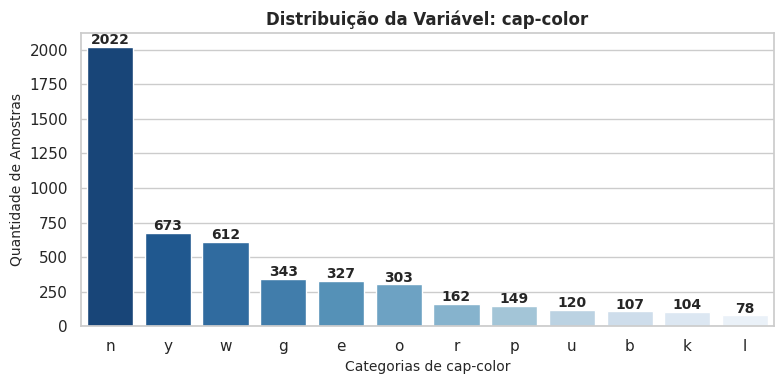

..................................................

 Coluna: DOES-BRUISE-OR-BLEED
Total de categorias únicas: 2
------------------------------


,Quantidade,Porcentagem (%)
does-bruise-or-bleed,,
f,4109,82.18
t,891,17.82


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


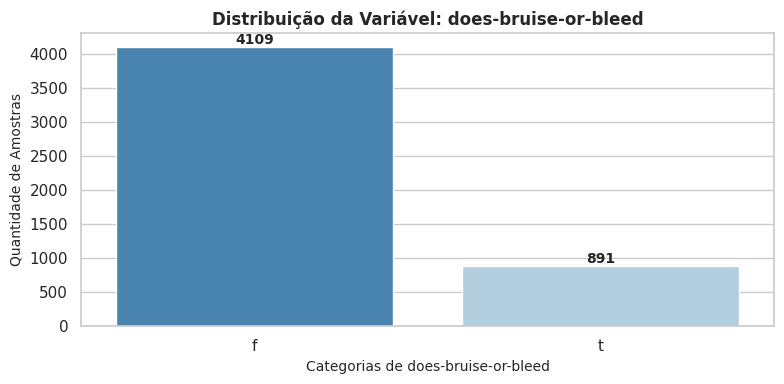

..................................................

 Coluna: GILL-ATTACHMENT
Total de categorias únicas: 8
------------------------------


,Quantidade,Porcentagem (%)
gill-attachment,,
a,1009,20.18
d,901,18.02
Nulo,809,16.18
x,611,12.22
s,477,9.54
p,462,9.24
e,418,8.36
f,313,6.26


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


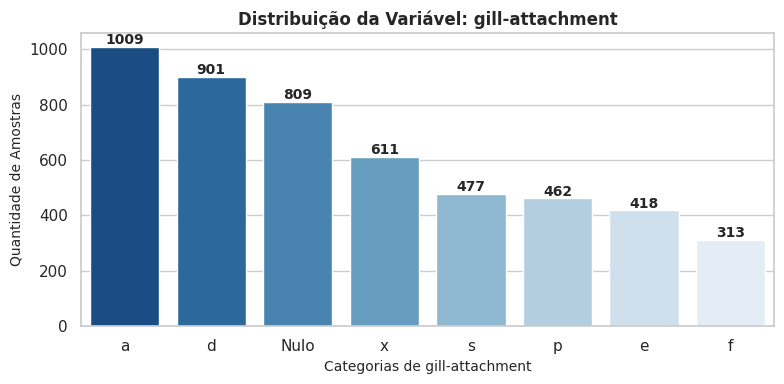

..................................................

 Coluna: GILL-SPACING
Total de categorias únicas: 4
------------------------------


,Quantidade,Porcentagem (%)
gill-spacing,,
Nulo,2048,40.96
c,2005,40.10
d,634,12.68
f,313,6.26


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


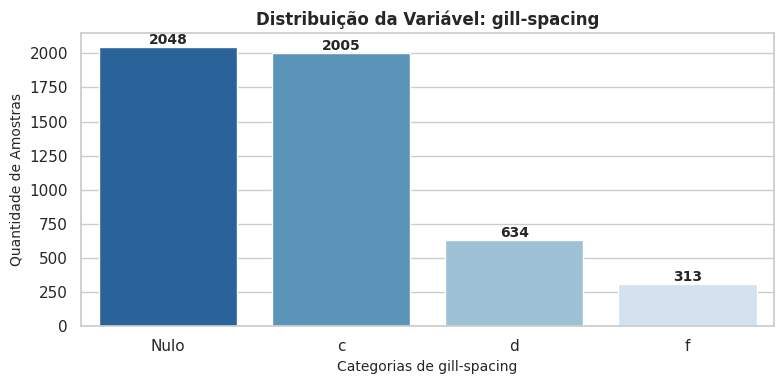

..................................................

 Coluna: GILL-COLOR
Total de categorias únicas: 12
------------------------------


,Quantidade,Porcentagem (%)
gill-color,,
w,1523,30.46
y,779,15.58
n,742,14.84
p,493,9.86
g,358,7.16
f,313,6.26
o,261,5.22
k,182,3.64
r,107,2.14


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


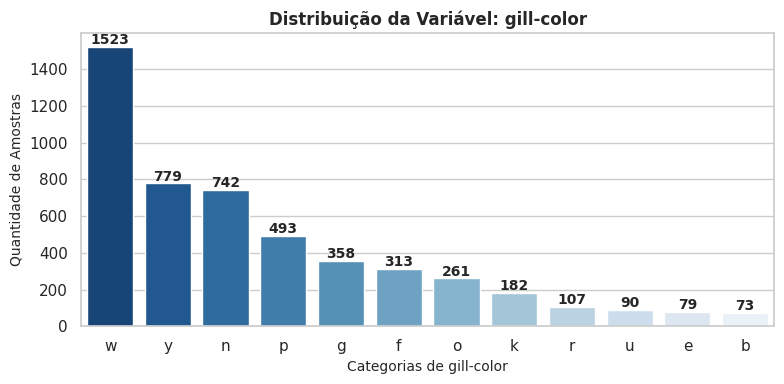

..................................................

 Coluna: STEM-COLOR
Total de categorias únicas: 13
------------------------------


,Quantidade,Porcentagem (%)
stem-color,,
w,1888,37.76
n,1491,29.82
y,610,12.20
g,225,4.50
o,186,3.72
e,163,3.26
u,120,2.40
f,89,1.78
p,89,1.78


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


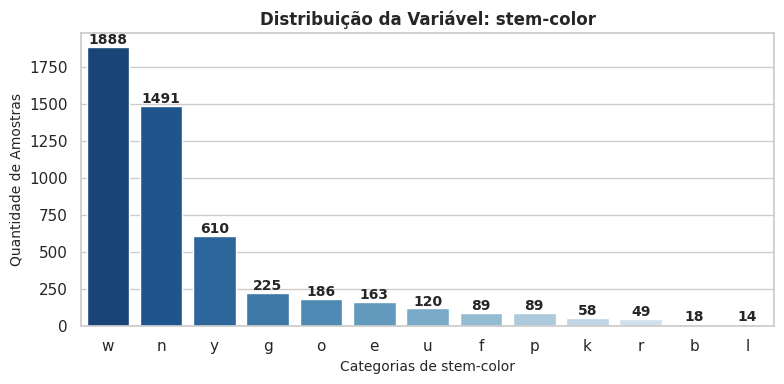

..................................................

 Coluna: HAS-RING
Total de categorias únicas: 2
------------------------------


,Quantidade,Porcentagem (%)
has-ring,,
f,3772,75.44
t,1228,24.56


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


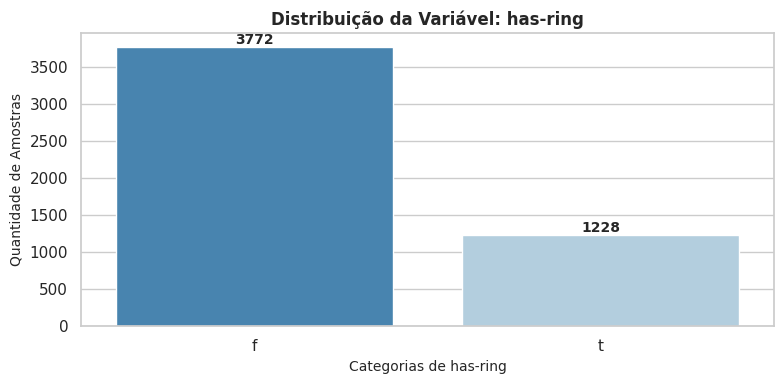

..................................................

 Coluna: RING-TYPE
Total de categorias únicas: 9
------------------------------


,Quantidade,Porcentagem (%)
ring-type,,
f,3988,79.76
Nulo,198,3.96
e,176,3.52
z,165,3.30
p,120,2.40
g,114,2.28
l,109,2.18
r,101,2.02
m,29,0.58


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


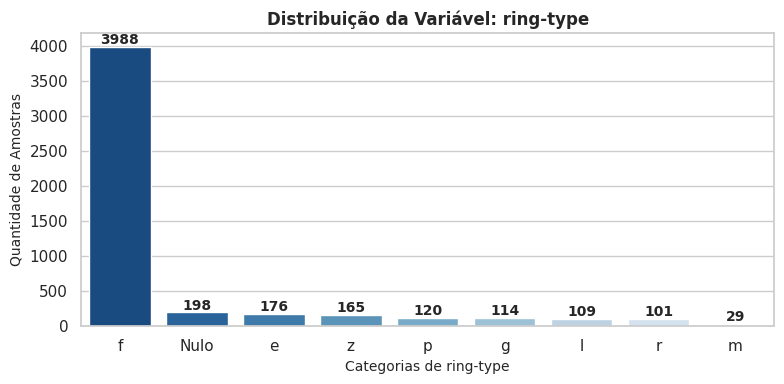

..................................................

 Coluna: HABITAT
Total de categorias únicas: 8
------------------------------


,Quantidade,Porcentagem (%)
habitat,,
d,3608,72.16
g,624,12.48
l,275,5.50
m,240,4.80
h,190,3.80
w,28,0.56
p,27,0.54
u,8,0.16


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


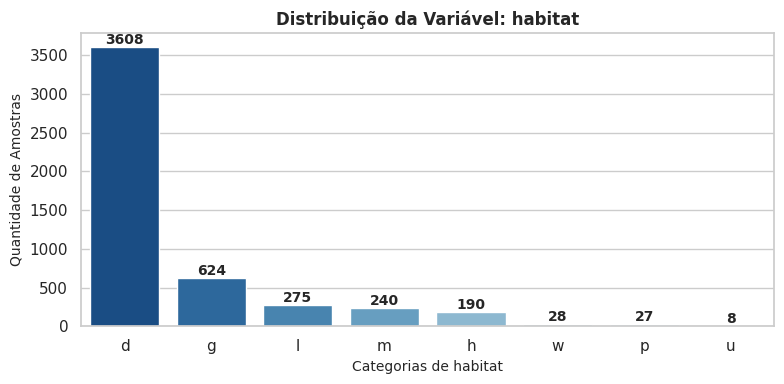

..................................................

 Coluna: SEASON
Total de categorias únicas: 4
------------------------------


,Quantidade,Porcentagem (%)
season,,
a,2482,49.64
u,1883,37.66
w,425,8.50
s,210,4.20


/tmp/ipykernel_517/871733091.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


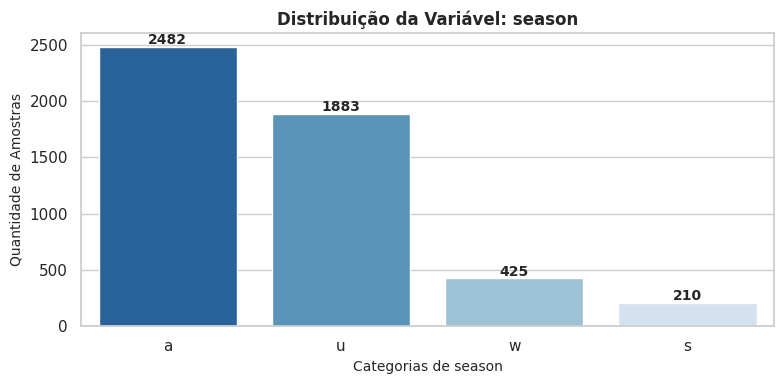

..................................................


In [ ]:
colunas_categoricas = [col for col in df.columns if df[col].dtype == 'object' or df[col].dtype.name == 'category']

print("ANÁLISE COMPLETA DE VARIÁVEIS CATEGÓRICAS")
print("="*60)

sns.set_theme(style="whitegrid")

for col in colunas_categoricas:

    col_temporaria = df[col].fillna('Nulo')
    total_categorias = col_temporaria.nunique()

    print(f"\n Coluna: {col.upper()}")
    print(f"Total de categorias únicas: {total_categorias}")
    print("-" * 30)

    contagem = col_temporaria.value_counts()
    porcentagem = col_temporaria.value_counts(normalize=True) * 100

    df_analise = pd.DataFrame({
        'Quantidade': contagem,
        'Porcentagem (%)': porcentagem.round(2)
    })

    display(df_analise)

    plt.figure(figsize=(8, 4))

    ax = sns.countplot(
        x=col_temporaria,
        order=contagem.index,
        palette='Blues_r'
    )

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(
                p.get_x() + p.get_width()/2.,
                height + (max(contagem) * 0.01),
                f'{int(height)}',
                ha="center",
                fontsize=10,
                fontweight='bold'
            )

    plt.title(f'Distribuição da Variável: {col}', fontsize=12, fontweight='bold')
    plt.xlabel(f'Categorias de {col}', fontsize=10)
    plt.ylabel('Quantidade de Amostras', fontsize=10)
    plt.tight_layout()

    plt.show()
    print("." * 50)

### Colunas Completas Numéricas

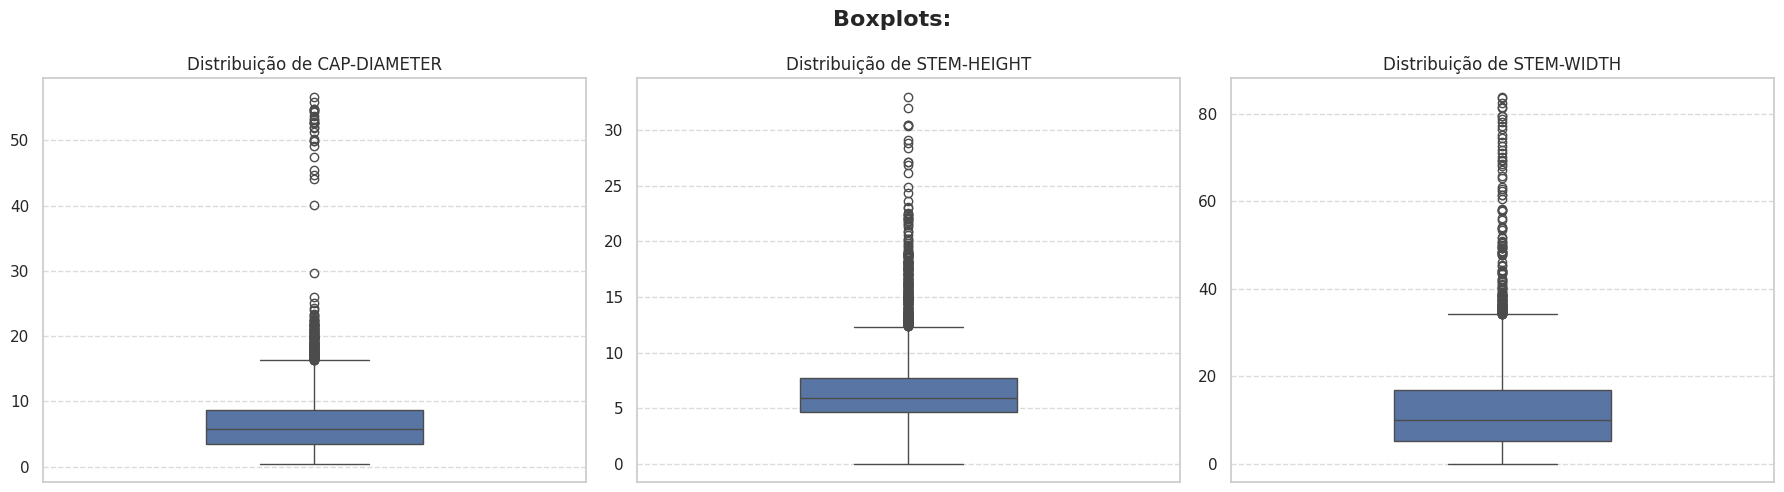


 COLUNA: CAP-DIAMETER
  • Mínimo absoluto: 0.44
  • Quartil 1: 3.45
  • Mediana:  5.80
  • Média:          6.74
  • Quartil 3: 8.60
  • Máximo absoluto: 56.72
  • Limite Sup: 16.32
  • Limite Inf: -4.27

 COLUNA: STEM-HEIGHT
  • Mínimo absoluto: 0.00
  • Quartil 1: 4.62
  • Mediana:  5.90
  • Média:          6.56
  • Quartil 3: 7.71
  • Máximo absoluto: 33.03
  • Limite Sup: 12.34
  • Limite Inf: -0.01

 COLUNA: STEM-WIDTH
  • Mínimo absoluto: 0.00
  • Quartil 1: 5.13
  • Mediana:  10.01
  • Média:          12.17
  • Quartil 3: 16.74
  • Máximo absoluto: 83.88
  • Limite Sup: 34.16
  • Limite Inf: -12.29


In [ ]:
colunas_numericas = ['cap-diameter', 'stem-height', 'stem-width']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplots:', fontsize=16, fontweight='bold')

for i, col in enumerate(colunas_numericas):
    df[col] = pd.to_numeric(df[col], errors='coerce')

    sns.boxplot(ax=axes[i], y=col, data=df, color='#4c72b0', width=0.4)
    axes[i].set_title(f'Distribuição de {col.upper()}', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

for col in colunas_numericas:
    dados_limpos = df[col].dropna()

    if dados_limpos.empty:
        print(f"\nColuna '{col}' não possui dados numéricos válidos.")
        continue

    minimo = dados_limpos.min()
    q1 = dados_limpos.quantile(0.25)
    mediana = dados_limpos.median()
    media = dados_limpos.mean()
    q3 = dados_limpos.quantile(0.75)
    maximo = dados_limpos.max()

    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_superiores = dados_limpos[dados_limpos > limite_superior]
    max_outlier = outliers_superiores.max() if not outliers_superiores.empty else "Nenhum outlier acima do limite"

    print(f"\n COLUNA: {col.upper()}")
    print(f"  • Mínimo absoluto: {minimo:.2f}")
    print(f"  • Quartil 1: {q1:.2f}")
    print(f"  • Mediana:  {mediana:.2f}")
    print(f"  • Média:          {media:.2f}")
    print(f"  • Quartil 3: {q3:.2f}")
    print(f"  • Máximo absoluto: {maximo:.2f}")
    print(f"  • Limite Sup: {limite_superior:.2f}")
    print(f"  • Limite Inf: {limite_inferior:.2f}")
    print("="*60)

## Tratamento dos dados

### Ring Type - Has Ring



In [ ]:
print(pd.crosstab(df['has-ring'], df['ring-type'], dropna=False))

ring-type    e     f    g    l   m    p    r    z  NaN
has-ring                                              
f            0  3772    0    0   0    0    0    0    0
t          176   216  114  109  29  120  101  165  198


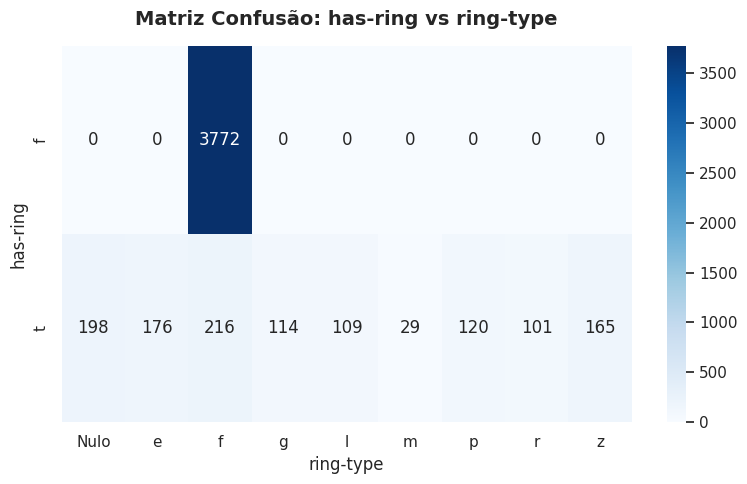

In [ ]:
df_plot = df.copy()
df_plot['ring-type'] = df_plot['ring-type'].fillna('Nulo')

crosstab_data = pd.crosstab(df_plot['has-ring'], df_plot['ring-type'])

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='Blues', cbar=True, square=False)

plt.title('Matriz Confusão: has-ring vs ring-type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ring-type', fontsize=12)
plt.ylabel('has-ring', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
df.loc[(df["has-ring"] == "t") & (df["ring-type"] == "f"), "has-ring"] = "f"

In [ ]:
df.loc[df['ring-type'] == 'f', 'has-ring'] = 'f'

moda_com_anel = df[df['has-ring'] == 't']['ring-type'].mode()[0]
print(f"A moda real para quem tem anel é: '{moda_com_anel}'")

df['ring-type'] = df['ring-type'].fillna(moda_com_anel)

A moda real para quem tem anel é: 'e'


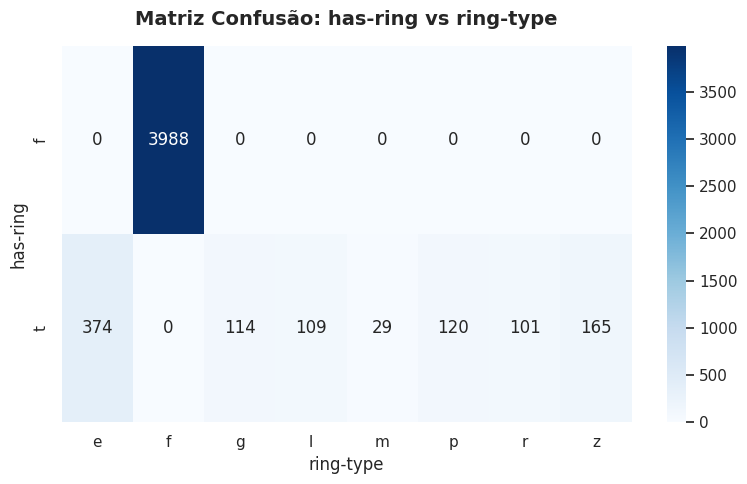

In [ ]:
df_plot = df.copy()
df_plot['ring-type'] = df_plot['ring-type'].fillna('Nulo')

crosstab_data = pd.crosstab(df_plot['has-ring'], df_plot['ring-type'])

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_data, annot=True, fmt='d', cmap='Blues', cbar=True, square=False)

plt.title('Matriz Confusão: has-ring vs ring-type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ring-type', fontsize=12)
plt.ylabel('has-ring', fontsize=12)

plt.tight_layout()
plt.show()

### Gill Colunas

In [ ]:
cols = ['gill-attachment', 'gill-spacing', 'gill-color']
print(df[cols].isnull().sum())
print(df[cols].isnull().mean().mul(100).round(2))

gill-attachment     809
gill-spacing       2048
gill-color            0
dtype: int64
gill-attachment    16.18
gill-spacing       40.96
gill-color          0.00
dtype: float64


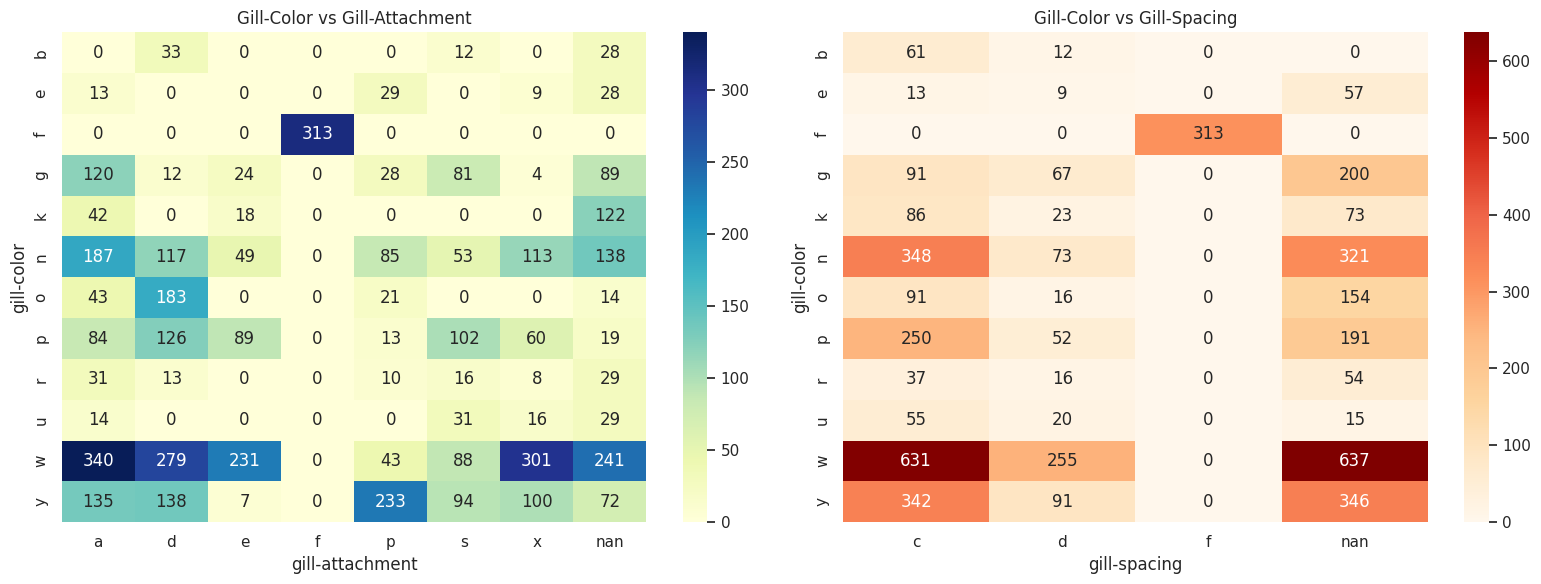

In [ ]:
cols = ["gill-attachment", "gill-spacing", "gill-color"]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
matriz_color_attachment = pd.crosstab(
    df["gill-color"], df["gill-attachment"], dropna=False
)
sns.heatmap(matriz_color_attachment, annot=True, cmap="YlGnBu", fmt="g")
plt.title("Gill-Color vs Gill-Attachment")

plt.subplot(1, 2, 2)
matriz_color_spacing = pd.crosstab(
    df["gill-color"], df["gill-spacing"], dropna=False
)
sns.heatmap(matriz_color_spacing, annot=True, cmap="OrRd", fmt="g")
plt.title("Gill-Color vs Gill-Spacing")

plt.tight_layout()
plt.show()

In [ ]:
df["gill-attachment"] = df.groupby("gill-color")["gill-attachment"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "valor_padrao")
)

df["gill-spacing"] = df.groupby("gill-color")["gill-spacing"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "valor_padrao")
)

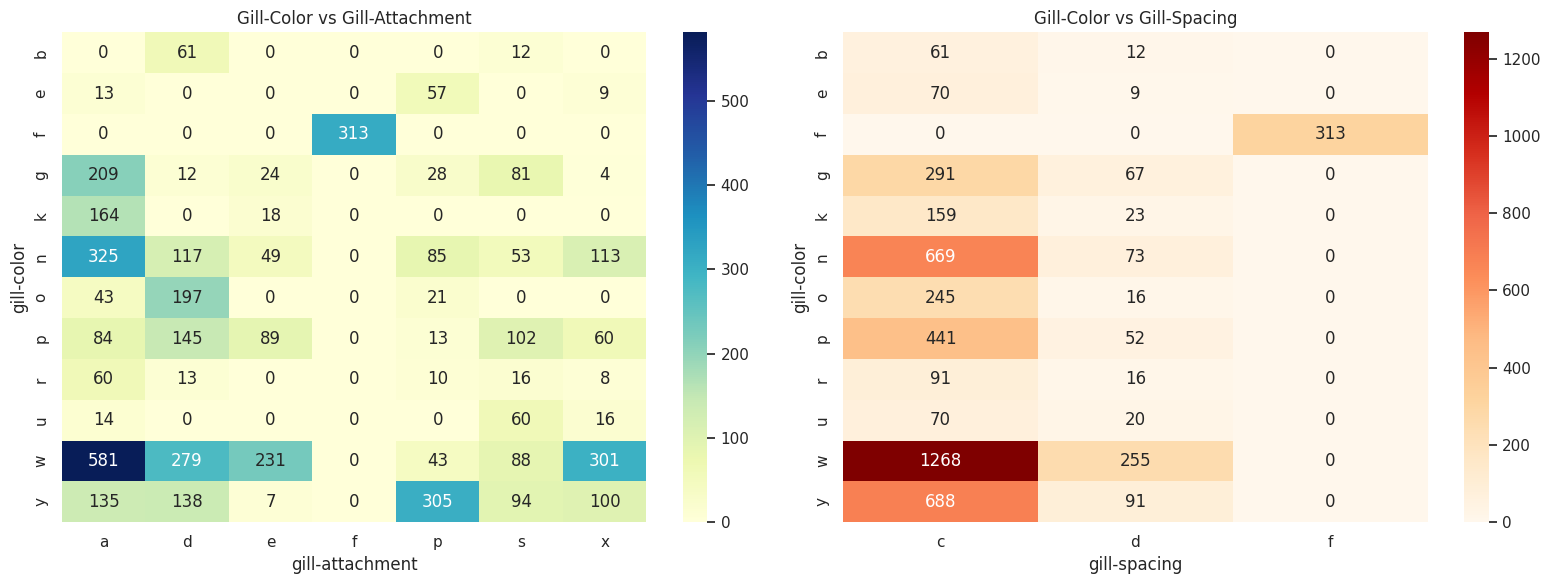

In [ ]:
cols = ["gill-attachment", "gill-spacing", "gill-color"]

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
matriz_color_attachment = pd.crosstab(
    df["gill-color"], df["gill-attachment"], dropna=False
)
sns.heatmap(matriz_color_attachment, annot=True, cmap="YlGnBu", fmt="g")
plt.title("Gill-Color vs Gill-Attachment")

plt.subplot(1, 2, 2)
matriz_color_spacing = pd.crosstab(
    df["gill-color"], df["gill-spacing"], dropna=False
)
sns.heatmap(matriz_color_spacing, annot=True, cmap="OrRd", fmt="g")
plt.title("Gill-Color vs Gill-Spacing")

plt.tight_layout()
plt.show()

### Cap Surface

/tmp/ipykernel_517/2181065095.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], data=df_antes_grafico, x='cap-surface', palette='magma', order=ordem_categorias)
/tmp/ipykernel_517/2181065095.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
/tmp/ipykernel_517/2181065095.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1], data=df, x='cap-surface', palette='magma', order=df['c

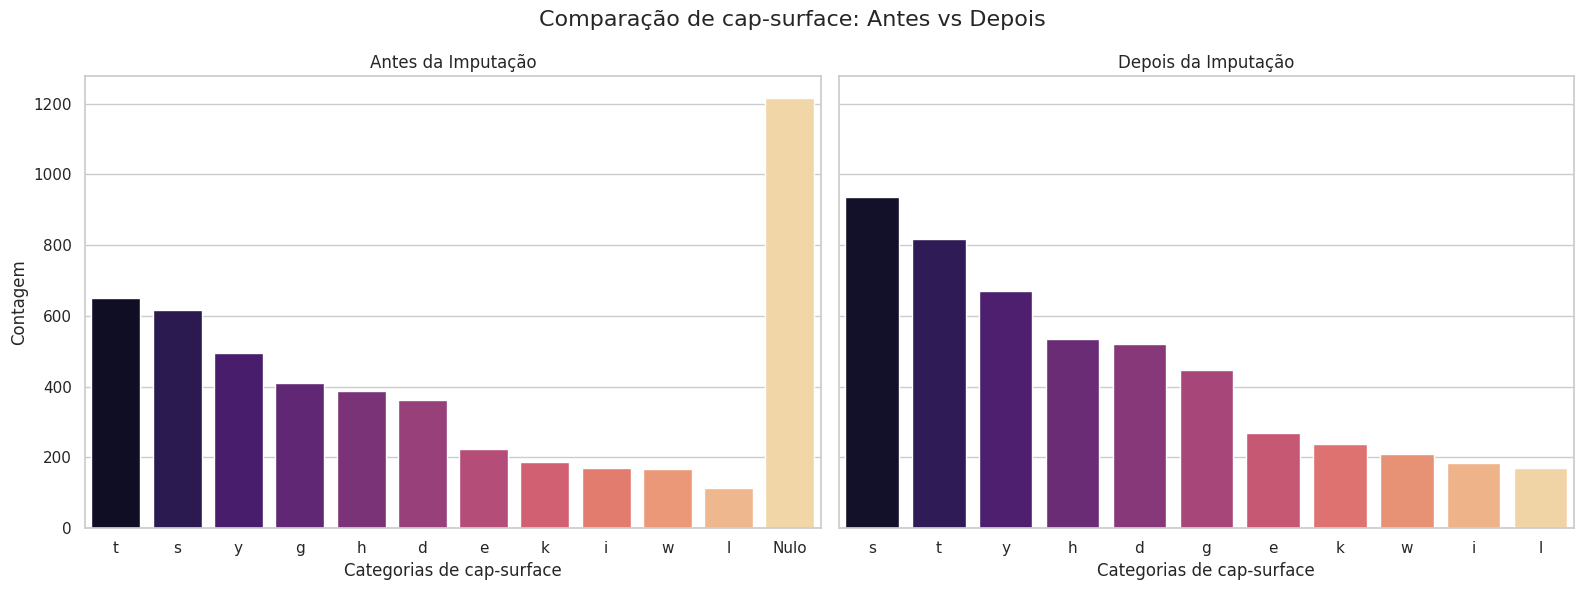

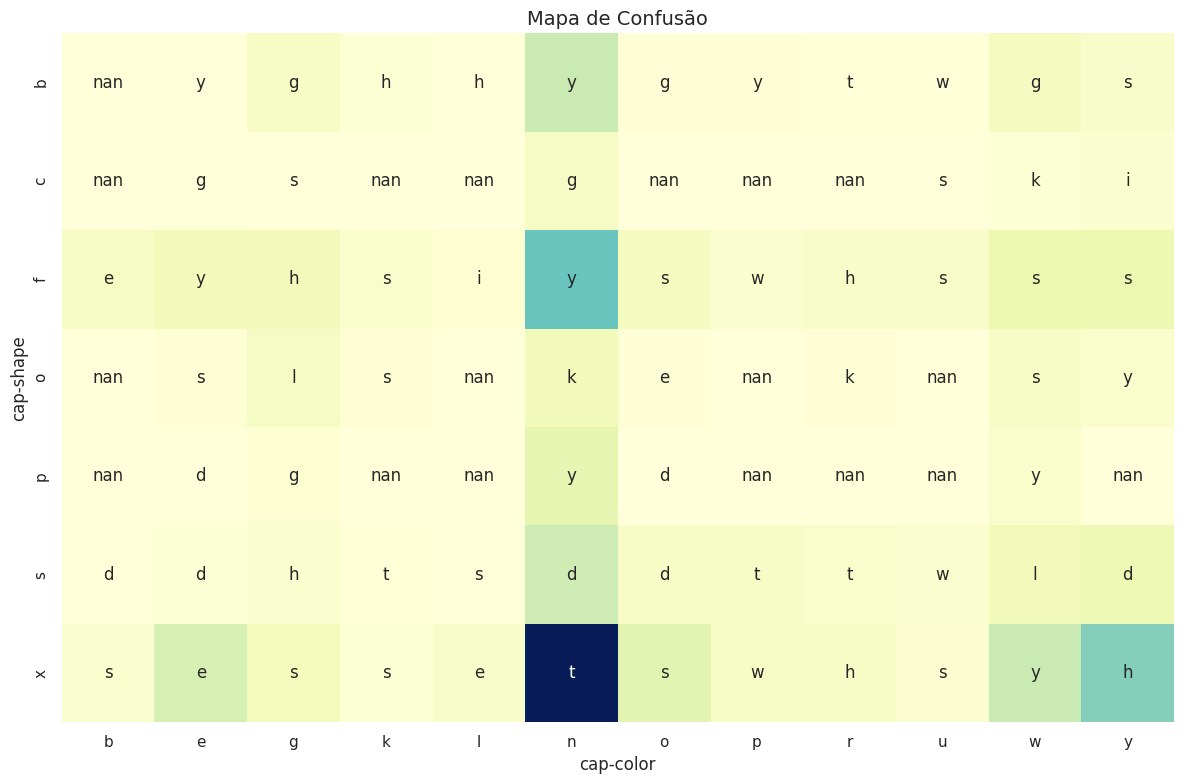

In [ ]:
sns.set_theme(style="whitegrid")

df = df.copy()


df_antes_grafico = df.copy()
df_antes_grafico['cap-surface'] = df_antes_grafico['cap-surface'].fillna('Nulo')

ordem_categorias = list(df['cap-surface'].dropna().value_counts().index) + ['Nulo']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Comparação de cap-surface: Antes vs Depois', fontsize=16)

sns.countplot(ax=axes[0], data=df_antes_grafico, x='cap-surface', palette='magma', order=ordem_categorias)
axes[0].set_title('Antes da Imputação')
axes[0].set_xlabel('Categorias de cap-surface')
axes[0].set_ylabel('Contagem')

df['cap-surface'] = df.groupby(['cap-shape', 'cap-color'])['cap-surface'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)
moda_geral = df['cap-surface'].mode()[0]
df['cap-surface'] = df['cap-surface'].fillna(moda_geral)

sns.countplot(ax=axes[1], data=df, x='cap-surface', palette='magma', order=df['cap-surface'].dropna().value_counts().index)
axes[1].set_title('Depois da Imputação')
axes[1].set_xlabel('Categorias de cap-surface')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

def obter_moda(x):
    return x.mode()[0] if not x.mode().empty else "X"

tabela_gemeos = df.groupby(['cap-shape', 'cap-color'])['cap-surface'].agg(obter_moda).unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(df.groupby(['cap-shape', 'cap-color']).size().unstack().fillna(0),
            annot=tabela_gemeos, fmt='', cmap='YlGnBu', cbar=False)
plt.title('Mapa de Confusão', fontsize=14)
plt.xlabel('cap-color')
plt.ylabel('cap-shape')
plt.tight_layout()
plt.show()

In [ ]:
contagem_antes = df_antes_grafico["cap-surface"].value_counts()

contagem_depois = df["cap-surface"].value_counts()

df_comparativo = pd.DataFrame(
    {"Antes": contagem_antes, "Depois": contagem_depois}
).fillna(0)

df_comparativo["Diferença (Preenchidos)"] = (
    df_comparativo["Depois"] - df_comparativo["Antes"]
)

print("## Distribuição dos Valores da Imputação ##")
print(df_comparativo.astype(int))

## Distribuição dos Valores da Imputação ##
             Antes  Depois  Diferença (Preenchidos)
cap-surface                                        
Nulo          1216       0                    -1216
d              362     520                      158
e              224     270                       46
g              410     448                       38
h              388     536                      148
i              171     185                       14
k              187     238                       51
l              113     170                       57
s              617     935                      318
t              650     816                      166
w              168     211                       43
y              494     671                      177


## Métricas de Classificação

### Desbalanceamento das Classes

In [ ]:
contagem = df['class'].value_counts()
percentual = df['class'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Quantidade': contagem, 'Porcentagem (%)': percentual.round(2)}))

razao = contagem.max() / contagem.min()
print(f"Razão entre a classe majoritária e a minoritária: {razao:.2f}")

,Quantidade,Porcentagem (%)
class,,
p,2775,55.5
e,2225,44.5


Razão entre a classe majoritária e a minoritária: 1.25


### Regressão Logística

======= RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA =======
               precision    recall  f1-score   support

   Edible (e)       0.73      0.73      0.73       668
Poisonous (p)       0.78      0.79      0.79       832

     accuracy                           0.76      1500
    macro avg       0.76      0.76      0.76      1500
 weighted avg       0.76      0.76      0.76      1500

Acurácia Final no Conjunto de Teste: 0.7613

======= MATRIZ DE CONFUSÃO =======


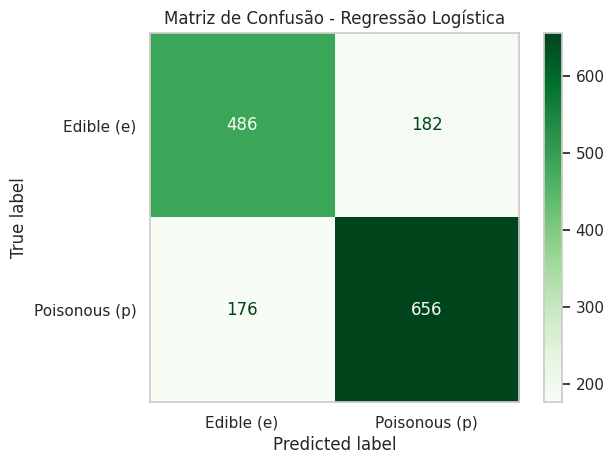

In [ ]:
df_preprocessado_lr = df.copy()

colunas_numericas = ['cap-diameter', 'stem-height', 'stem-width']
colunas_categoricas = [col for col in df_preprocessado_lr.columns if col not in colunas_numericas and col != 'class']

for col in colunas_categoricas:
    df_preprocessado_lr[col] = df_preprocessado_lr[col].fillna('missing')

for col in colunas_numericas:
    df_preprocessado_lr[col] = df_preprocessado_lr[col].fillna(df_preprocessado_lr[col].median())

    q1 = df_preprocessado_lr[col].quantile(0.25)
    q3 = df_preprocessado_lr[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    df_preprocessado_lr[col] = df_preprocessado_lr[col].clip(lower=limite_inferior, upper=limite_superior)

X = df_preprocessado_lr.drop(columns=['class'])
y = df_preprocessado_lr['class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

preprocessador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ]
)

modelo_lr = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('classificador', LogisticRegression(max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train_raw, y_train)

y_pred_lr = modelo_lr.predict(X_test_raw)

print("======= RELATÓRIO DE CLASSIFICAÇÃO - REGRESSÃO LOGÍSTICA =======")
print(classification_report(y_test, y_pred_lr, target_names=['Edible (e)', 'Poisonous (p)']))

acuracia_final_lr = accuracy_score(y_test, y_pred_lr)
print(f"Acurácia Final no Conjunto de Teste: {acuracia_final_lr:.4f}\n")

print("======= MATRIZ DE CONFUSÃO =======")
matriz_confusao_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao_lr, display_labels=['Edible (e)', 'Poisonous (p)'])
disp.plot(cmap='Greens')
plt.grid(False)
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

In [ ]:
ohe = modelo_lr.named_steps['preprocessador'].named_transformers_['cat']
nomes_colunas_ohe = ohe.get_feature_names_out(colunas_categoricas)

print(f"Total de colunas geradas pelo OneHotEncoder: {len(nomes_colunas_ohe)}")
print(nomes_colunas_ohe)

X_train_transformado = modelo_lr.named_steps['preprocessador'].transform(X_train_raw)

nomes_completos = colunas_numericas + list(nomes_colunas_ohe)

df_transformado = pd.DataFrame(
    X_train_transformado.toarray() if hasattr(X_train_transformado, "toarray") else X_train_transformado,
    columns=nomes_completos,
    index=X_train_raw.index
)

df_transformado.head()

Total de colunas geradas pelo OneHotEncoder: 89
['cap-shape_b' 'cap-shape_c' 'cap-shape_f' 'cap-shape_o' 'cap-shape_p'
 'cap-shape_s' 'cap-shape_x' 'cap-surface_d' 'cap-surface_e'
 'cap-surface_g' 'cap-surface_h' 'cap-surface_i' 'cap-surface_k'
 'cap-surface_l' 'cap-surface_s' 'cap-surface_t' 'cap-surface_w'
 'cap-surface_y' 'cap-color_b' 'cap-color_e' 'cap-color_g' 'cap-color_k'
 'cap-color_l' 'cap-color_n' 'cap-color_o' 'cap-color_p' 'cap-color_r'
 'cap-color_u' 'cap-color_w' 'cap-color_y' 'does-bruise-or-bleed_f'
 'does-bruise-or-bleed_t' 'gill-attachment_a' 'gill-attachment_d'
 'gill-attachment_e' 'gill-attachment_f' 'gill-attachment_p'
 'gill-attachment_s' 'gill-attachment_x' 'gill-spacing_c' 'gill-spacing_d'
 'gill-spacing_f' 'gill-color_b' 'gill-color_e' 'gill-color_f'
 'gill-color_g' 'gill-color_k' 'gill-color_n' 'gill-color_o'
 'gill-color_p' 'gill-color_r' 'gill-color_u' 'gill-color_w'
 'gill-color_y' 'stem-color_b' 'stem-color_e' 'stem-color_f'
 'stem-color_g' 'stem-color_k'

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
1053,2.150392,-0.252058,1.904283,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3179,-1.433906,-0.304634,-1.275069,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1559,0.443705,-1.371180,1.301445,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3183,-0.209377,0.108465,2.639398,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1463,0.606975,1.193788,0.378902,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Total de erros: 358 de 1500 (23.9%)



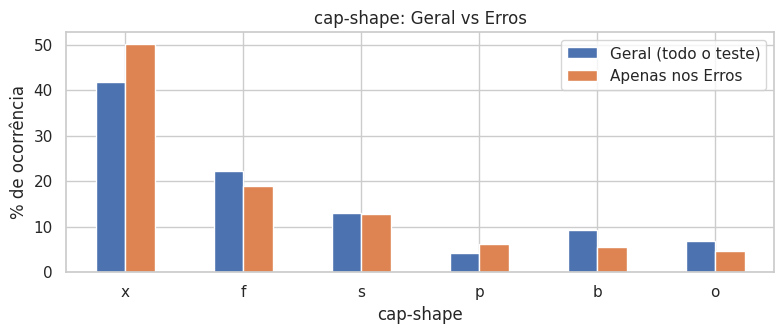

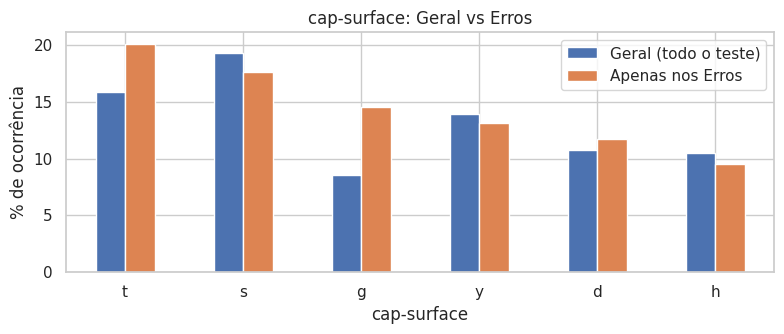

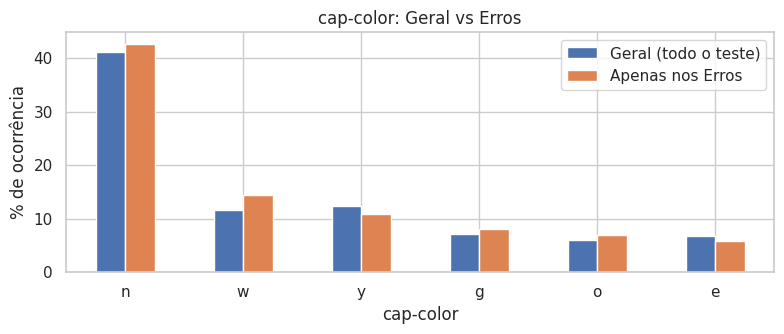

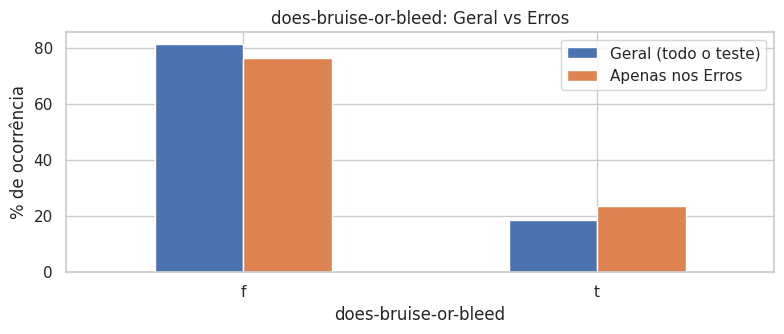

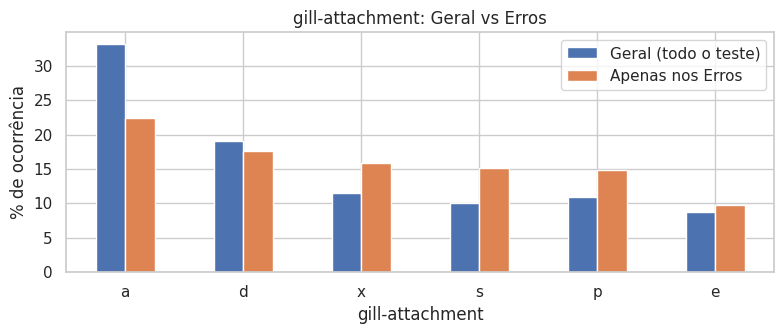

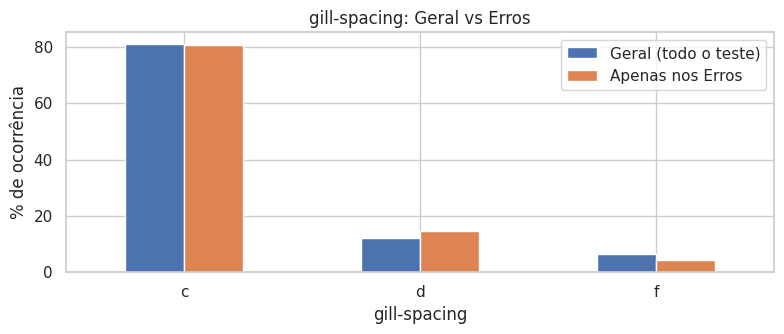

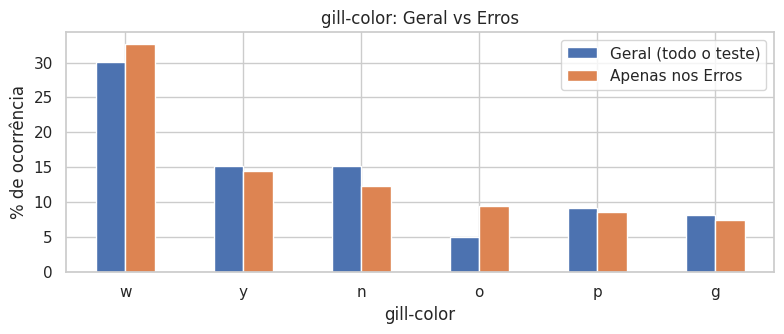

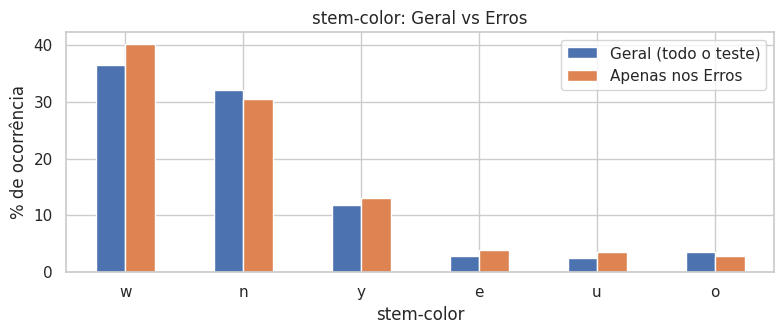

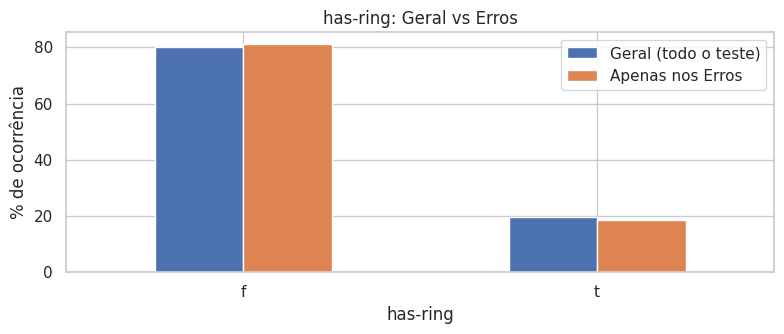

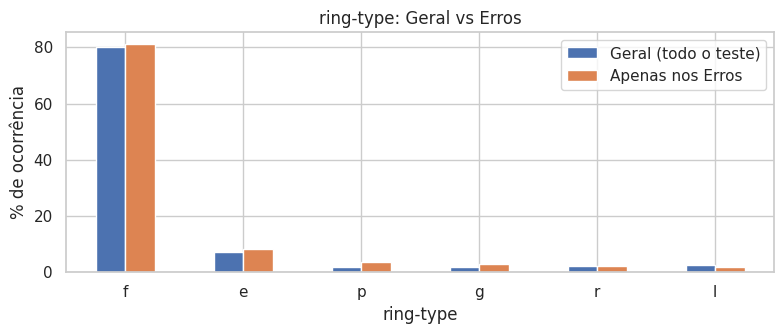

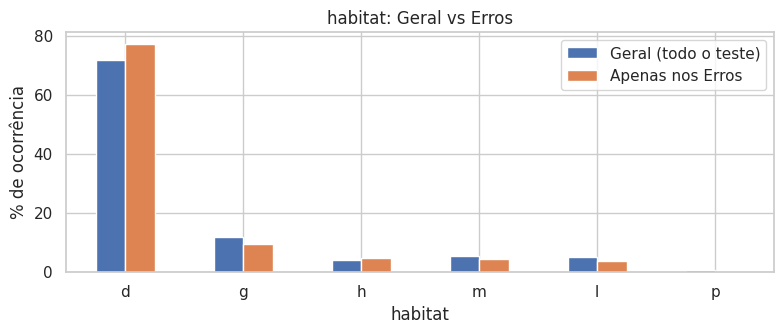

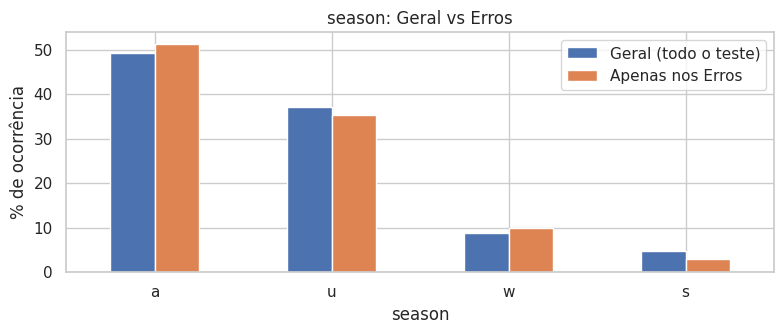

In [ ]:
df_analise_erros = X_test_raw.copy()
df_analise_erros['classe_real'] = y_test.values
df_analise_erros['classe_prevista'] = y_pred_lr
df_analise_erros['acertou'] = df_analise_erros['classe_real'] == df_analise_erros['classe_prevista']

df_erros = df_analise_erros[df_analise_erros['acertou'] == False]

print(f"Total de erros: {len(df_erros)} de {len(df_analise_erros)} ({len(df_erros)/len(df_analise_erros)*100:.1f}%)\n")

for col in colunas_categoricas:
    dist_geral = df_analise_erros[col].value_counts(normalize=True) * 100
    dist_erros = df_erros[col].value_counts(normalize=True) * 100

    comparacao = pd.DataFrame({
        'Geral (todo o teste)': dist_geral,
        'Apenas nos Erros': dist_erros
    }).fillna(0)

    comparacao = comparacao.sort_values('Apenas nos Erros', ascending=False).head(6)

    comparacao.plot(kind='bar', figsize=(8, 3.5), color=['#4C72B0', '#DD8452'])
    plt.title(f'{col}: Geral vs Erros')
    plt.ylabel('% de ocorrência')
    plt.xticks(rotation=0)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [ ]:
resultados = []

for col in colunas_categoricas:
    dist_geral = df_analise_erros[col].value_counts(normalize=True)
    dist_erros = df_erros[col].value_counts(normalize=True)

    for categoria in dist_erros.index:
        prop_geral = dist_geral.get(categoria, 0)
        prop_erro = dist_erros.get(categoria, 0)
        diferenca = prop_erro - prop_geral

        resultados.append({
            'coluna': col,
            'categoria': categoria,
            'prop_geral (%)': round(prop_geral * 100, 1),
            'prop_erro (%)': round(prop_erro * 100, 1),
            'diferenca (p.p.)': round(diferenca * 100, 1)
        })

df_ranking = pd.DataFrame(resultados).sort_values('diferenca (p.p.)', ascending=False)

print("======= TOP 15 CATEGORIAS MAIS SOBRE-REPRESENTADAS NOS ERROS =======")
print(df_ranking.head(15).to_string(index=False))

======= TOP 15 CATEGORIAS MAIS SOBRE-REPRESENTADAS NOS ERROS =======
              coluna categoria  prop_geral (%)  prop_erro (%)  diferenca (p.p.)
           cap-shape         x            41.8           50.3               8.5
         cap-surface         g             8.6           14.5               5.9
             habitat         d            71.9           77.4               5.5
does-bruise-or-bleed         t            18.5           23.5               5.0
     gill-attachment         s            10.1           15.1               5.0
     gill-attachment         x            11.5           15.9               4.5
          gill-color         o             5.0            9.5               4.5
         cap-surface         t            15.9           20.1               4.2
     gill-attachment         p            10.9           14.8               3.9
          stem-color         w            36.5           40.2               3.7
           cap-color         w            11.7     

In [ ]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, pos_label='p')
rec_lr = recall_score(y_test, y_pred_lr, pos_label='p')
f1_lr = f1_score(y_test, y_pred_lr, pos_label='p')

y_prob_lr = modelo_lr.predict_proba(X_test_raw)[:,1]
y_test_bin = (y_test == 'p').astype(int)
auc_lr = roc_auc_score(y_test_bin, y_prob_lr)

### Árvore de Decisão

In [ ]:
df_preprocessado_tree = df.copy()

colunas_numericas = ['cap-diameter', 'stem-height', 'stem-width']
colunas_categoricas = [col for col in df_preprocessado_tree.columns if col not in colunas_numericas and col != 'class']

for col in colunas_categoricas:
    df_preprocessado_tree[col] = df_preprocessado_tree[col].fillna('missing')

for col in colunas_numericas:
    df_preprocessado_tree[col] = df_preprocessado_tree[col].fillna(df_preprocessado_tree[col].median())

    q1 = df_preprocessado_tree[col].quantile(0.25)
    q3 = df_preprocessado_tree[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    df_preprocessado_tree[col] = df_preprocessado_tree[col].clip(lower=limite_inferior, upper=limite_superior)

X_final = df_preprocessado_tree.drop(columns=['class'])

X_final = pd.get_dummies(X_final, columns=colunas_categoricas, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(df_preprocessado_tree['class'])

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.3, stratify=y, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"Proporção da classe positiva (p=venenoso) no treino: {y_train.mean():.3f}")
print(f"Proporção da classe positiva (p=venenoso) no teste:  {y_test.mean():.3f}")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
print("StratifiedKFold(10) definido para validação cruzada e busca de hiperparâmetros.")

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

grid_tree = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=cv, scoring='f1', n_jobs=-1)

t0 = time.time()
grid_tree.fit(X_train, y_train)
tempo_treino_tree = time.time() - t0

print("\nMelhores parâmetros encontrados:")
print(grid_tree.best_params_)
print(f"\nMelhor F1 médio (validação cruzada, treino): {grid_tree.best_score_:.4f}")
print(f"Tempo total de busca + treino: {tempo_treino_tree:.1f}s")

Treino: 3500 amostras | Teste: 1500 amostras
Proporção da classe positiva (p=venenoso) no treino: 0.555
Proporção da classe positiva (p=venenoso) no teste:  0.555
StratifiedKFold(10) definido para validação cruzada e busca de hiperparâmetros.

Melhores parâmetros encontrados:
{'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Melhor F1 médio (validação cruzada, treino): 0.9711
Tempo total de busca + treino: 107.7s


#### Avaliação do Conjunto de Teste

In [ ]:
melhor_tree = grid_tree.best_estimator_
y_pred_tree = melhor_tree.predict(X_test)
y_proba_tree = melhor_tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_proba_tree)

print(f"Accuracy:  {acc_tree:.4f}")
print(f"Precision: {prec_tree:.4f}")
print(f"Recall:    {rec_tree:.4f}")
print(f"F1-score:  {f1_tree:.4f}")
print(f"ROC-AUC:   {auc_tree:.4f}")
print()
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[str(c) for c in le.classes_]
    )
)

Accuracy:  0.9587
Precision: 0.9572
Recall:    0.9688
F1-score:  0.9630
ROC-AUC:   0.9574

Classification Report:
              precision    recall  f1-score   support

           e       0.96      0.95      0.95       668
           p       0.96      0.97      0.96       832

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500



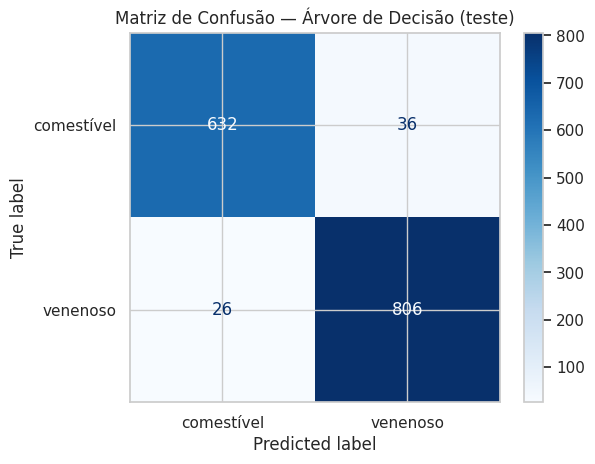

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['comestível', 'venenoso']).plot(cmap='Blues')
plt.title('Matriz de Confusão — Árvore de Decisão (teste)')
plt.show()

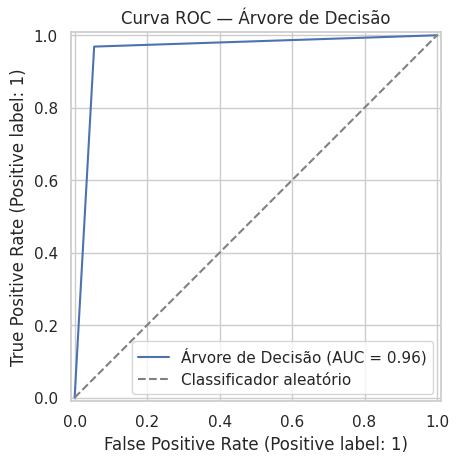

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name='Árvore de Decisão')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador aleatório')
plt.title('Curva ROC — Árvore de Decisão')
plt.legend()
plt.show()

#### Analise de Erro

Total de erros: 62 de 1500 (4.1%)

--- Análise de Erros: cap-shape ---
           Total no Teste  Total de Erros  Taxa de Erro (%)
cap-shape                                                  
o                     102               6               5.9
c                      38               2               5.3
x                     627              30               4.8
f                     333              13               3.9
s                     197               7               3.6
b                     140               3               2.1
p                      63               1               1.6
----------------------------------------


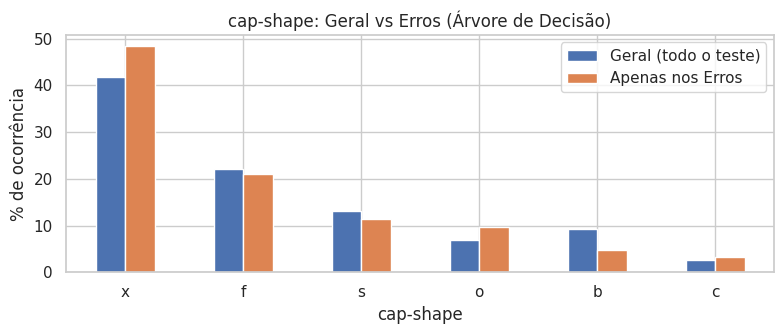



--- Análise de Erros: cap-surface ---
             Total no Teste  Total de Erros  Taxa de Erro (%)
cap-surface                                                  
w                        64               5               7.8
d                       161              12               7.5
y                       209              11               5.3
h                       158               7               4.4
k                        72               3               4.2
i                        62               2               3.2
s                       290               9               3.1
t                       238               7               2.9
e                        76               2               2.6
l                        41               1               2.4
g                       129               3               2.3
----------------------------------------


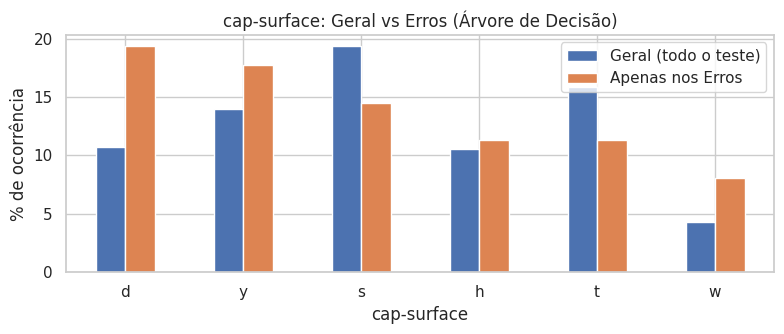



--- Análise de Erros: cap-color ---
           Total no Teste  Total de Erros  Taxa de Erro (%)
cap-color                                                  
b                      29             2.0               6.9
g                     107             6.0               5.6
n                     619            32.0               5.2
u                      44             2.0               4.5
r                      48             2.0               4.2
l                      25             1.0               4.0
e                     101             4.0               4.0
w                     175             6.0               3.4
p                      43             1.0               2.3
o                      91             2.0               2.2
y                     186             4.0               2.2
k                      32             0.0               0.0
----------------------------------------


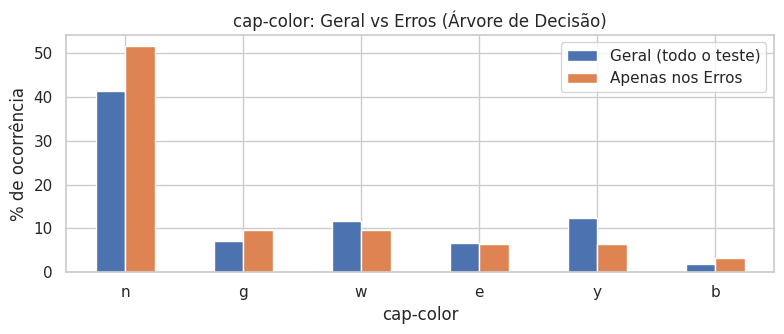



--- Análise de Erros: does-bruise-or-bleed ---
                      Total no Teste  Total de Erros  Taxa de Erro (%)
does-bruise-or-bleed                                                  
f                               1223              54               4.4
t                                277               8               2.9
----------------------------------------


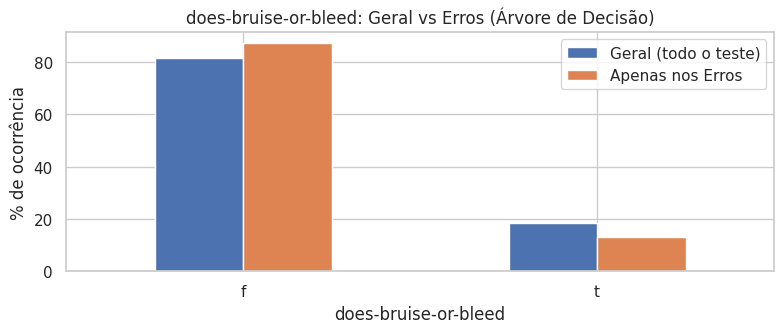



--- Análise de Erros: gill-attachment ---
                 Total no Teste  Total de Erros  Taxa de Erro (%)
gill-attachment                                                  
x                           172              12               7.0
f                            98               6               6.1
p                           164               7               4.3
a                           498              20               4.0
s                           152               5               3.3
e                           131               4               3.1
d                           285               8               2.8
----------------------------------------


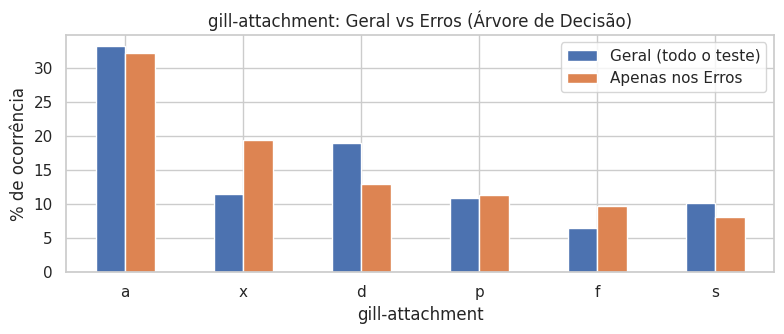



--- Análise de Erros: gill-spacing ---
              Total no Teste  Total de Erros  Taxa de Erro (%)
gill-spacing                                                  
f                         98               6               6.1
c                       1218              51               4.2
d                        184               5               2.7
----------------------------------------


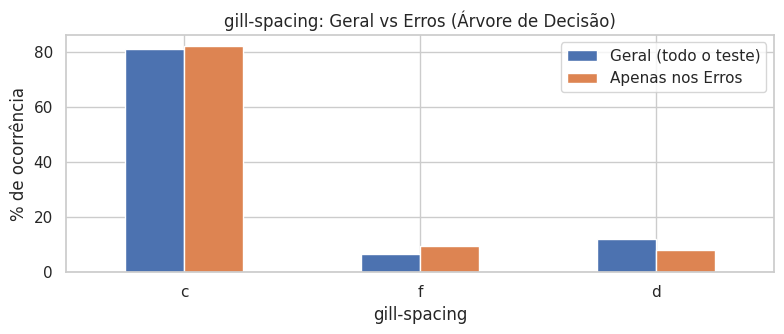



--- Análise de Erros: gill-color ---
            Total no Teste  Total de Erros  Taxa de Erro (%)
gill-color                                                  
r                       39             3.0               7.7
f                       98             6.0               6.1
w                      451            25.0               5.5
o                       75             4.0               5.3
e                       20             1.0               5.0
g                      122             5.0               4.1
p                      137             5.0               3.6
y                      229             7.0               3.1
n                      227             6.0               2.6
b                       20             0.0               0.0
k                       57             0.0               0.0
u                       25             0.0               0.0
----------------------------------------


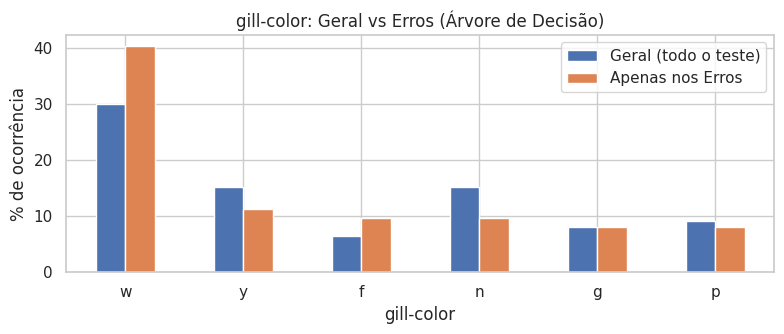



--- Análise de Erros: stem-color ---
            Total no Teste  Total de Erros  Taxa de Erro (%)
stem-color                                                  
l                        3             1.0              33.3
p                       21             2.0               9.5
g                       76             7.0               9.2
e                       43             2.0               4.7
n                      482            21.0               4.4
w                      548            23.0               4.2
o                       54             2.0               3.7
u                       37             1.0               2.7
y                      177             3.0               1.7
k                       13             0.0               0.0
f                       29             0.0               0.0
b                        5             0.0               0.0
r                       12             0.0               0.0
----------------------------------------


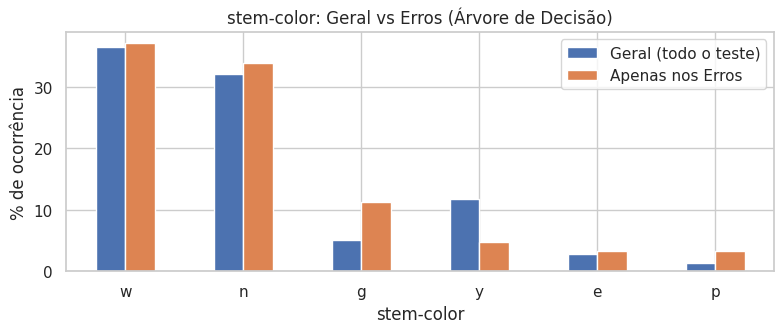



--- Análise de Erros: has-ring ---
          Total no Teste  Total de Erros  Taxa de Erro (%)
has-ring                                                  
f                   1204              57               4.7
t                    296               5               1.7
----------------------------------------


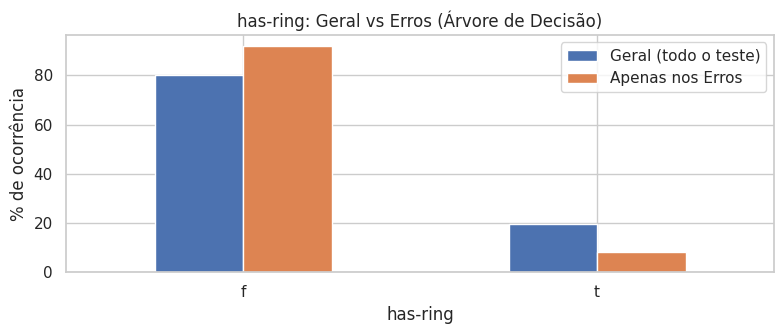



--- Análise de Erros: ring-type ---
           Total no Teste  Total de Erros  Taxa de Erro (%)
ring-type                                                  
f                    1204            57.0               4.7
g                      29             1.0               3.4
r                      33             1.0               3.0
e                     109             3.0               2.8
l                      40             0.0               0.0
m                       9             0.0               0.0
p                      28             0.0               0.0
z                      48             0.0               0.0
----------------------------------------


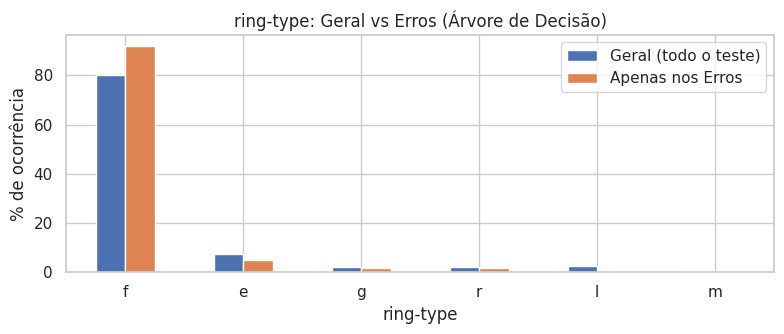



--- Análise de Erros: habitat ---
         Total no Teste  Total de Erros  Taxa de Erro (%)
habitat                                                  
h                    62             9.0              14.5
l                    79             4.0               5.1
d                  1078            46.0               4.3
m                    82             2.0               2.4
g                   177             1.0               0.6
p                     9             0.0               0.0
u                     3             0.0               0.0
w                    10             0.0               0.0
----------------------------------------


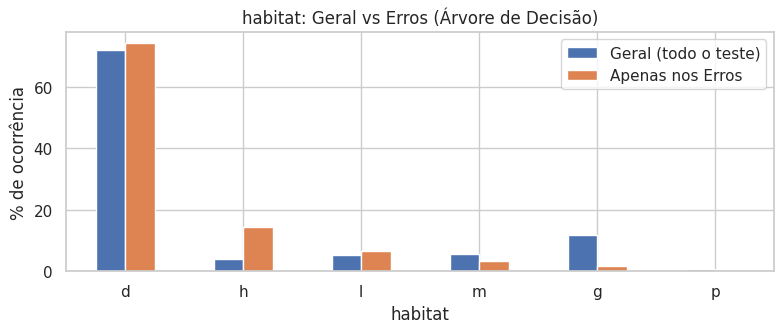



--- Análise de Erros: season ---
        Total no Teste  Total de Erros  Taxa de Erro (%)
season                                                  
u                  556              27               4.9
s                   71               3               4.2
a                  741              29               3.9
w                  132               3               2.3
----------------------------------------


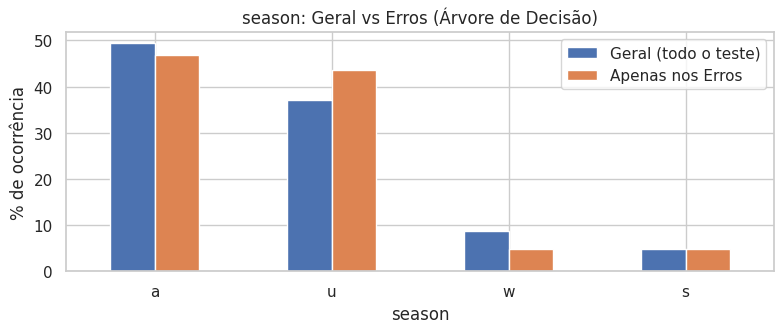

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Gerar as previsões
y_pred_tree = grid_tree.predict(X_test)

# 2. Criar o DataFrame de análise
df_analise_erros = df_preprocessado_tree.loc[X_test.index].copy()

df_analise_erros['classe_real'] = y_test
df_analise_erros['classe_prevista'] = y_pred_tree
df_analise_erros['acertou'] = df_analise_erros['classe_real'] == df_analise_erros['classe_prevista']

df_erros = df_analise_erros[df_analise_erros['acertou'] == False]

print(f"Total de erros: {len(df_erros)} de {len(df_analise_erros)} ({len(df_erros)/len(df_analise_erros)*100:.1f}%)\n")

# 3. Analisar cada coluna categórica
for col in colunas_categoricas:

    # --- NOVO CÁLCULO: Porcentagem de erro para cada categoria ---
    total_na_categoria = df_analise_erros[col].value_counts()
    erros_na_categoria = df_erros[col].value_counts()

    tabela_taxa_erro = pd.DataFrame({
        'Total no Teste': total_na_categoria,
        'Total de Erros': erros_na_categoria
    }).fillna(0) # Preenche com 0 caso a categoria não tenha tido erros

    tabela_taxa_erro['Taxa de Erro (%)'] = (tabela_taxa_erro['Total de Erros'] / tabela_taxa_erro['Total no Teste']) * 100
    tabela_taxa_erro = tabela_taxa_erro.sort_values('Taxa de Erro (%)', ascending=False)

    print(f"--- Análise de Erros: {col} ---")
    print(tabela_taxa_erro[['Total no Teste', 'Total de Erros', 'Taxa de Erro (%)']].round(1))
    print("-" * 40)
    # -------------------------------------------------------------

    # Código original dos gráficos
    dist_geral = df_analise_erros[col].value_counts(normalize=True) * 100
    dist_erros = df_erros[col].value_counts(normalize=True) * 100

    comparacao = pd.DataFrame({
        'Geral (todo o teste)': dist_geral,
        'Apenas nos Erros': dist_erros
    }).fillna(0)

    comparacao = comparacao.sort_values('Apenas nos Erros', ascending=False).head(6)

    comparacao.plot(kind='bar', figsize=(8, 3.5), color=['#4C72B0', '#DD8452'])
    plt.title(f'{col}: Geral vs Erros (Árvore de Decisão)')
    plt.ylabel('% de ocorrência')
    plt.xticks(rotation=0)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    print("\n") # Adiciona um espaço extra entre o gráfico e a próxima variável

In [ ]:
resultados = []

for col in colunas_categoricas:
    dist_geral = df_analise_erros[col].value_counts(normalize=True)
    dist_erros = df_erros[col].value_counts(normalize=True)

    for categoria in dist_erros.index:
        prop_geral = dist_geral.get(categoria, 0)
        prop_erro = dist_erros.get(categoria, 0)
        diferenca = prop_erro - prop_geral

        resultados.append({
            'coluna': col,
            'categoria': categoria,
            'prop_geral (%)': round(prop_geral * 100, 1),
            'prop_erro (%)': round(prop_erro * 100, 1),
            'diferenca (p.p.)': round(diferenca * 100, 1)
        })

df_ranking = pd.DataFrame(resultados).sort_values('diferenca (p.p.)', ascending=False)

print("======= TOP 15 CATEGORIAS MAIS SOBRE-REPRESENTADAS NOS ERROS =======")
print(df_ranking.head(15).to_string(index=False))

======= TOP 15 CATEGORIAS MAIS SOBRE-REPRESENTADAS NOS ERROS =======
              coluna categoria  prop_geral (%)  prop_erro (%)  diferenca (p.p.)
           ring-type         f            80.3           91.9              11.7
            has-ring         f            80.3           91.9              11.7
             habitat         h             4.1           14.5              10.4
           cap-color         n            41.3           51.6              10.3
          gill-color         w            30.1           40.3              10.3
         cap-surface         d            10.7           19.4               8.6
     gill-attachment         x            11.5           19.4               7.9
           cap-shape         x            41.8           48.4               6.6
              season         u            37.1           43.5               6.5
          stem-color         g             5.1           11.3               6.2
does-bruise-or-bleed         f            81.5     

#### Árvore

Profundidade da árvore: 20
Número de folhas: 176
Número total de nós: 351


,Atributo,Importância
1,stem-height,0.132180
2,stem-width,0.108609
0,cap-diameter,0.102700
37,gill-spacing_d,0.066229
69,ring-type_z,0.031762
31,gill-attachment_d,0.028675
9,cap-surface_e,0.020929
8,cap-shape_x,0.020440
26,cap-color_r,0.017905
14,cap-surface_l,0.017626


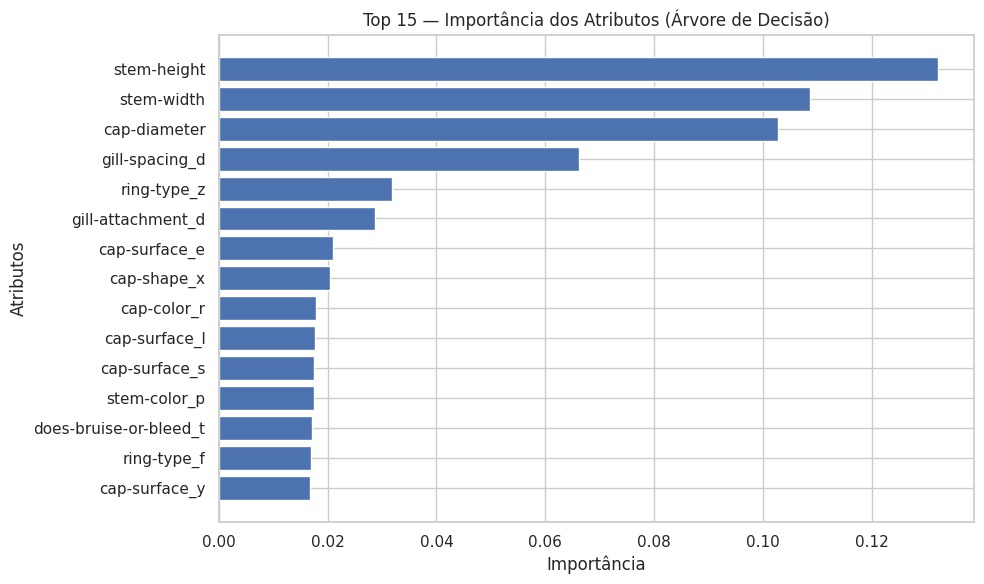

In [ ]:
arvore_final = melhor_tree
nomes_atributos = list(X_final.columns)

print(f"Profundidade da árvore: {arvore_final.get_depth()}")
print(f"Número de folhas: {arvore_final.get_n_leaves()}")
print(f"Número total de nós: {arvore_final.tree_.node_count}")

importancias = pd.DataFrame({
    'Atributo': nomes_atributos,
    'Importância': arvore_final.feature_importances_
}).sort_values(by='Importância', ascending=False)

display(importancias.head(15))

print("\n")
top15 = importancias.head(15).sort_values(by='Importância', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(top15['Atributo'], top15['Importância'], color='#4c72b0')
plt.title('Top 15 — Importância dos Atributos (Árvore de Decisão)')
plt.xlabel('Importância')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()

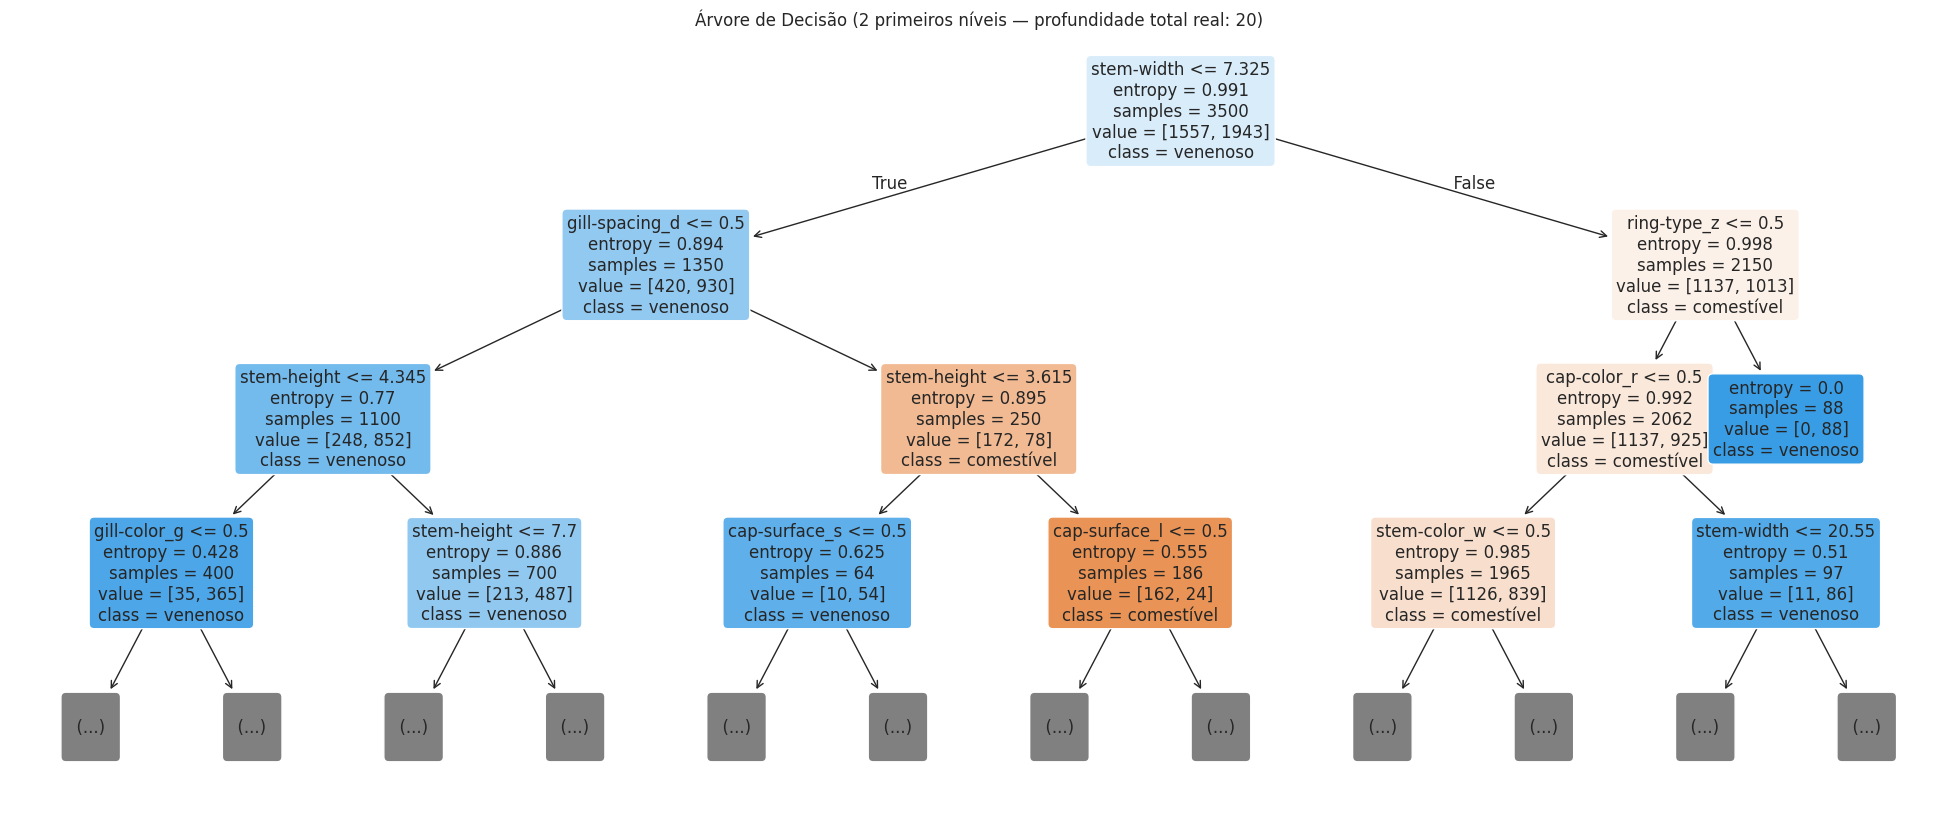

In [ ]:
plt.figure(figsize=(25, 10))
plot_tree(
    arvore_final,
    max_depth=3,
    feature_names=nomes_atributos,
    class_names=['comestível', 'venenoso'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title(f'Árvore de Decisão (2 primeiros níveis — profundidade total real: {arvore_final.get_depth()})')
plt.show()

#### Testando COM SMOTE e SEM SMOTE

In [ ]:
melhores_params_tree = grid_tree.best_params_

modelo_sem_smote = DecisionTreeClassifier(random_state=42, **melhores_params_tree)

pipeline_com_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(random_state=42, **melhores_params_tree))
])

metricas_cv = ['accuracy', 'precision', 'recall', 'f1']

resultado_sem = cross_validate(modelo_sem_smote, X_train, y_train, cv=cv, scoring=metricas_cv)
resultado_com = cross_validate(pipeline_com_smote, X_train, y_train, cv=cv, scoring=metricas_cv)

comparacao_smote = pd.DataFrame({
    'Sem SMOTE': [resultado_sem[f'test_{m}'].mean() for m in metricas_cv],
    'Com SMOTE': [resultado_com[f'test_{m}'].mean() for m in metricas_cv],
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score'])

comparacao_smote['Diferença'] = comparacao_smote['Com SMOTE'] - comparacao_smote['Sem SMOTE']
display(comparacao_smote.round(4))

,Sem SMOTE,Com SMOTE,Diferença
Accuracy,0.9680,0.9591,-0.0089
Precision,0.9737,0.9585,-0.0152
Recall,0.9686,0.9686,-0.0000
F1-score,0.9711,0.9635,-0.0076


### Comparando os Modelos

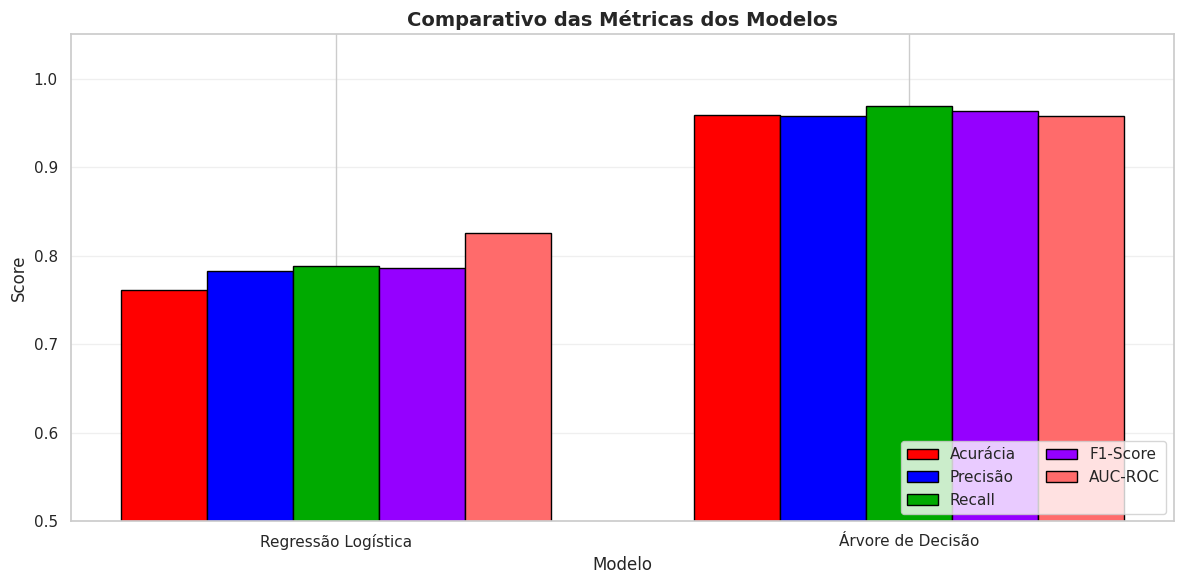

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_metricas = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia': [acc_lr, acc_tree],
    'Precisão': [prec_lr, prec_tree],
    'Recall': [rec_lr, rec_tree],
    'F1-Score': [f1_lr, f1_tree],
    'AUC-ROC': [auc_lr, auc_tree]
})

fig, ax = plt.subplots(figsize=(12,6))

x = np.arange(len(df_metricas['Modelo']))
largura = 0.15

metricas_plot = [
    'Acurácia',
    'Precisão',
    'Recall',
    'F1-Score',
    'AUC-ROC'
]

cores_barras = [
    '#FF0000',
    '#0000FF',
    '#00AA00',
    '#9500FF',
    '#ff6b6b'
]

for i, metrica in enumerate(metricas_plot):
    ax.bar(
        x + i*largura,
        df_metricas[metrica],
        largura,
        label=metrica,
        color=cores_barras[i],
        edgecolor='black'
    )

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'Comparativo das Métricas dos Modelos',
    fontsize=14,
    fontweight='bold'
)

ax.set_xticks(x + largura*2)
ax.set_xticklabels(df_metricas['Modelo'])

ax.set_ylim(0.5, 1.05)

ax.legend(loc='lower right', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()